# 変圧器油温（OT）予測 PoC

## 目的

本分析では、ETTデータセットのETTh1を使用し、変圧器の油温（OT）を予測するモデルを構築する。

過去の油温、電力負荷、時間情報などを利用してOTを予測し、
設備保全の判断を支援できる可能性について検証する。

また、単純な予測手法をBaselineとして、
複数の機械学習モデルと予測精度を比較する。

最終的には予測誤差の分析を行い、
モデルの有効性・課題・今後の改善方法について考察する。

## 1. ライブラリの読み込み

データの読み込み・加工にはPandas、数値計算にはNumPy、
グラフによる可視化にはMatplotlibを使用する。

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. データの読み込み

ETTh1データセットを読み込む。

ETTh1は1時間ごとに記録された時系列データであり、
電力負荷を表す複数の特徴量と、変圧器の油温を表すOTが含まれている。

本分析ではOTを予測対象とする。

In [3]:
df = pd.read_csv("data/ETTh1.csv")

## 3. データの確認

モデル構築の前に、データの内容や形式を確認する。

まず先頭のデータを表示し、各列にどのような値が入っているかを確認する。
また、データ数やデータの型、欠損値の有無、基本統計量についても確認する。

主な列は以下の通りである。

- date：観測日時
- HUFL / HULL：高負荷に関する特徴量
- MUFL / MULL：中負荷に関する特徴量
- LUFL / LULL：低負荷に関する特徴量
- OT：変圧器の油温（予測対象）

In [4]:
df.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [5]:
df.shape

(17420, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  str    
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), str(1)
memory usage: 1.1 MB


In [7]:
df.isnull().sum()

date    0
HUFL    0
HULL    0
MUFL    0
MULL    0
LUFL    0
LULL    0
OT      0
dtype: int64

In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17420 non-null  datetime64[us]
 1   HUFL    17420 non-null  float64       
 2   HULL    17420 non-null  float64       
 3   MUFL    17420 non-null  float64       
 4   MULL    17420 non-null  float64       
 5   LUFL    17420 non-null  float64       
 6   LULL    17420 non-null  float64       
 7   OT      17420 non-null  float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 1.1 MB


## 4. 探索的データ分析（EDA）

モデルを構築する前に、予測対象であるOTの特徴や時間的な傾向を確認する。

まずOTを時系列で可視化し、時間の経過によってどのように変化しているかを確認する。
また、時間帯や曜日によってOTに違いがあるかについても分析する。

さらに、時系列データでは過去の値が現在の値と関係している可能性があるため、
過去のOTと現在のOTの関係についても確認する。

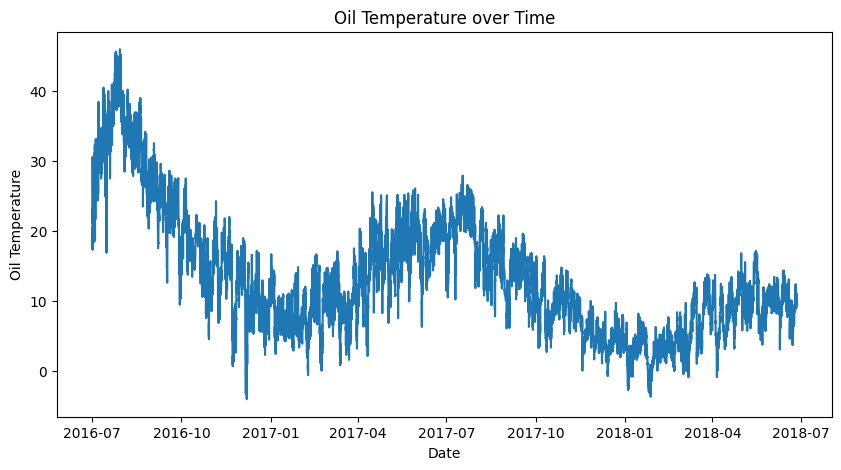

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df["date"], df["OT"])
plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.title("Oil Temperature over Time")
plt.show()

In [11]:
df.describe()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
count,17420,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000,17420.000000
mean,2017-06-28 21:30:00,7.375141,2.242242,4.300239,0.881568,3.066062,0.856932,13.324672
min,2016-07-01 00:00:00,-22.705999,-4.756000,-25.087999,-5.934000,-1.188000,-1.371000,-4.080000
25%,2016-12-29 10:45:00,5.827000,0.737000,3.296000,-0.284000,2.315000,0.670000,6.964000
50%,2017-06-28 21:30:00,8.774000,2.210000,5.970000,0.959000,2.833000,0.975000,11.396000
75%,2017-12-27 08:15:00,11.788000,3.684000,8.635000,2.203000,3.625000,1.218000,18.079000
max,2018-06-26 19:00:00,23.643999,10.114000,17.341000,7.747000,8.498000,3.046000,46.007000
std,NaN,7.067744,2.042342,6.826978,1.809293,1.164506,0.599552,8.566946


In [12]:
df.corr(numeric_only=True)

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
HUFL,1.000000,0.114672,0.987355,0.066002,0.291418,0.023606,0.059916
HULL,0.114672,1.000000,0.068817,0.930491,0.259487,0.377641,0.224354
MUFL,0.987355,0.068817,1.000000,0.046266,0.177491,-0.046519,0.050854
MULL,0.066002,0.930491,0.046266,1.000000,0.128607,0.069419,0.220004
LUFL,0.291418,0.259487,0.177491,0.128607,1.000000,0.334563,0.118836
LULL,0.023606,0.377641,-0.046519,0.069419,0.334563,1.000000,0.067455
OT,0.059916,0.224354,0.050854,0.220004,0.118836,0.067455,1.000000


In [13]:
correlation = df.corr(numeric_only=True)

correlation["OT"].sort_values(ascending=False)

OT      1.000000
HULL    0.224354
MULL    0.220004
LUFL    0.118836
LULL    0.067455
HUFL    0.059916
MUFL    0.050854
Name: OT, dtype: float64

## 5. 特徴量作成

モデルがOTを予測するために利用する特徴量を作成する。

日時データから、時刻（hour）、曜日（dayofweek）、月（month）を作成する。

また、EDAの結果から過去のOTと現在のOTに強い関係が確認されたため、
1時間前、24時間前、168時間前のOTをLag特徴量として利用する。

これらの時間情報、過去のOT、電力負荷に関する情報を組み合わせてOTを予測する。

In [14]:
df["hour"] = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

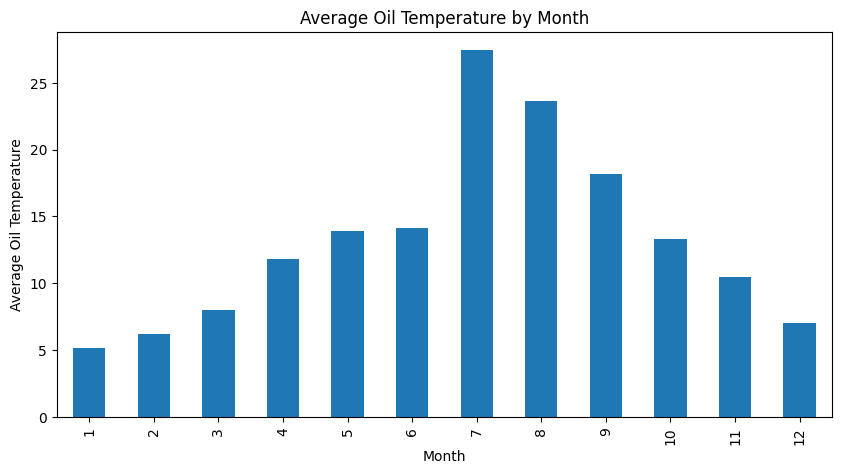

In [15]:
monthly_ot = df.groupby("month")["OT"].mean()

monthly_ot.plot(kind="bar", figsize=(10, 5))

plt.xlabel("Month")
plt.ylabel("Average Oil Temperature")
plt.title("Average Oil Temperature by Month")
plt.show()

1行目が1時間前の油温の特徴量で、それぞれ、1時間・1日・1週間前の油温を特徴量にする。

In [17]:
df["OT_lag1"] = df["OT"].shift(1)
df["OT_lag24"] = df["OT"].shift(24)
df["OT_lag168"] = df["OT"].shift(168)

In [18]:
lag_correlation = df[
    ["OT", "OT_lag1", "OT_lag24", "OT_lag168"]
].corr()

lag_correlation

,OT,OT_lag1,OT_lag24,OT_lag168
OT,1.000000,0.994256,0.940649,0.870099
OT_lag1,0.994256,1.000000,0.941705,0.869495
OT_lag24,0.940649,0.941705,1.000000,0.866380
OT_lag168,0.870099,0.869495,0.866380,1.000000


In [19]:
lag_correlation["OT"].sort_values(ascending=False)

OT           1.000000
OT_lag1      0.994256
OT_lag24     0.940649
OT_lag168    0.870099
Name: OT, dtype: float64

### EDAの結果

OTには強い時系列的な連続性が確認された。

特に、現在のOTと1時間前のOTの相関係数は約0.994となり、
非常に強い相関が確認された。

また、24時間前のOTとの相関は約0.941、
168時間（1週間）前のOTとの相関は約0.870となった。

この結果から、OTを予測する際には過去のOTが
重要な情報になると考えられる。

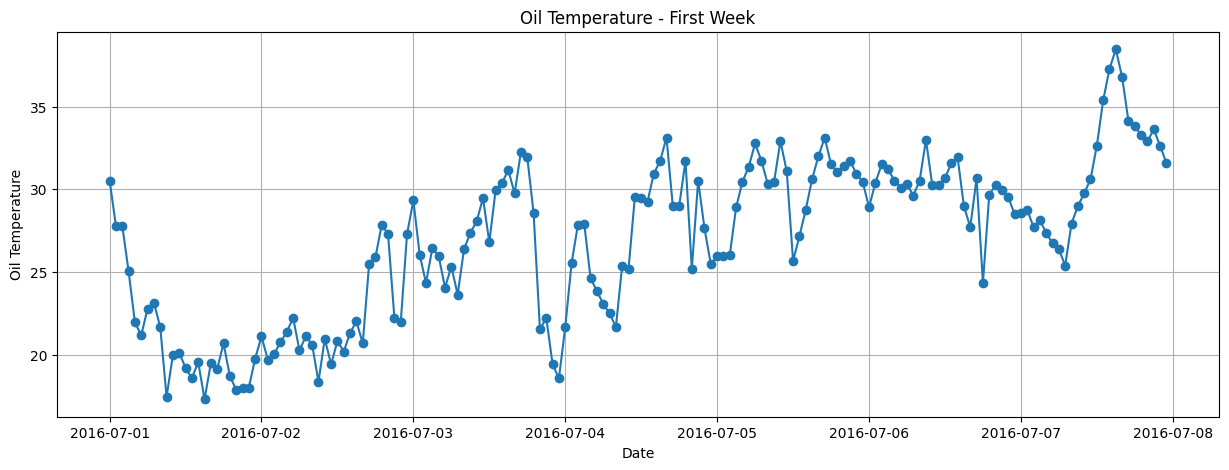

In [20]:
one_week = df.iloc[:24 * 7]

plt.figure(figsize=(15, 5))
plt.plot(one_week["date"], one_week["OT"], marker="o")

plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.title("Oil Temperature - First Week")
plt.grid()
plt.show()

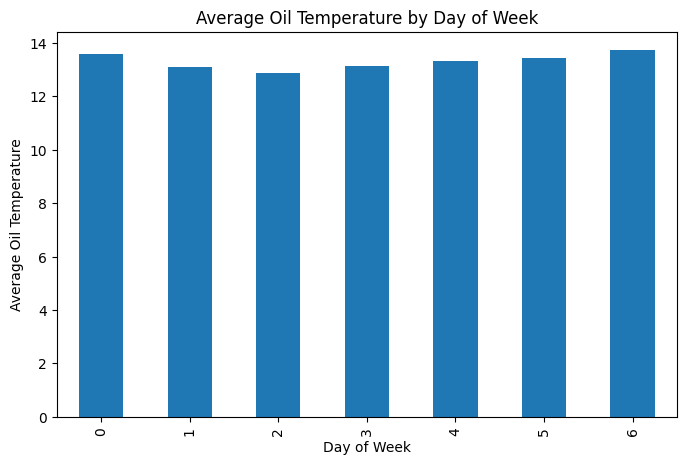

In [21]:
weekday_ot = df.groupby("dayofweek")["OT"].mean()

weekday_ot.plot(kind="bar", figsize=(8, 5))

plt.xlabel("Day of Week")
plt.ylabel("Average Oil Temperature")
plt.title("Average Oil Temperature by Day of Week")
plt.show()

In [ ]:
未来のデータを学習に使わないよう、時間順に前半80%を学習、後半20%をテストに分ける。

In [22]:
# 学習用80%、テスト用20%に時系列順で分割
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

print("Train:", train.shape)
print("Test:", test.shape)

print("Train period:", train["date"].min(), "〜", train["date"].max())
print("Test period :", test["date"].min(), "〜", test["date"].max())

Train: (13936, 14)
Test: (3484, 14)
Train period: 2016-07-01 00:00:00 〜 2018-02-01 15:00:00
Test period : 2018-02-01 16:00:00 〜 2018-06-26 19:00:00


In [23]:
# 1時間前のOTを予測値とする
test["baseline_pred"] = test["OT_lag1"]

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["OT"],
    test["baseline_pred"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["OT"],
        test["baseline_pred"]
    )
)

print("Baseline MAE :", mae)
print("Baseline RMSE:", rmse)

Baseline MAE : 0.4480861066471695
Baseline RMSE: 0.6541843541468318


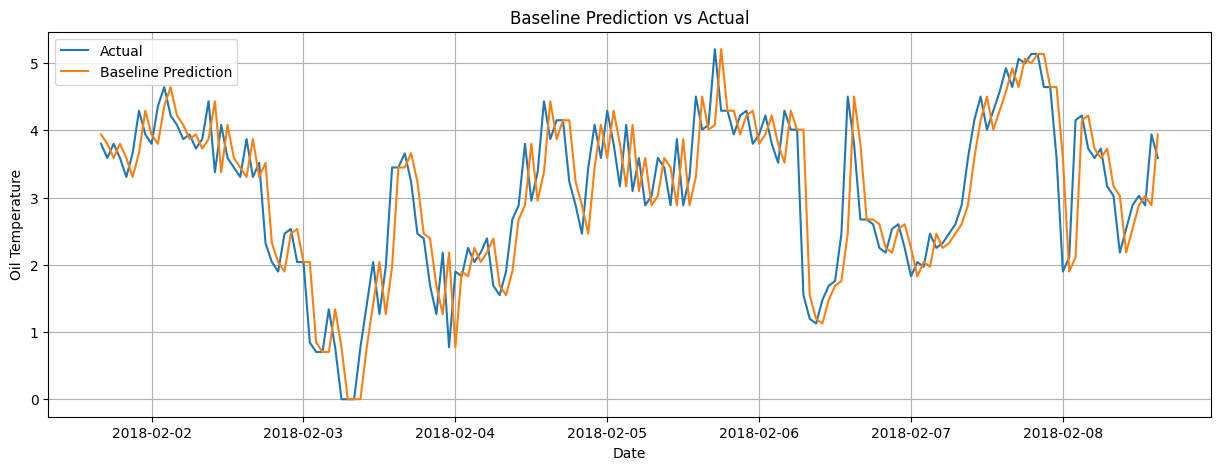

In [25]:
plot_test = test.iloc[:24 * 7]

plt.figure(figsize=(15, 5))

plt.plot(
    plot_test["date"],
    plot_test["OT"],
    label="Actual"
)

plt.plot(
    plot_test["date"],
    plot_test["baseline_pred"],
    label="Baseline Prediction"
)

plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.title("Baseline Prediction vs Actual")
plt.legend()
plt.grid()

plt.show()

In [26]:
features = [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL",
    "hour",
    "dayofweek",
    "month",
    "OT_lag1",
    "OT_lag24",
    "OT_lag168"
]

target = "OT"

In [27]:
train_ml = train.dropna(subset=features)
test_ml = test.dropna(subset=features)

X_train = train_ml[features]
y_train = train_ml[target]

X_test = test_ml[features]
y_test = test_ml[target]


In [28]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
linear_pred = linear_model.predict(X_test)

In [30]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

print("Baseline MAE :", mae)
print("Baseline RMSE:", rmse)

print("Linear MAE   :", linear_mae)
print("Linear RMSE  :", linear_rmse)

Baseline MAE : 0.4480861066471695
Baseline RMSE: 0.6541843541468318
Linear MAE   : 0.4338290436134983
Linear RMSE  : 0.6328428018154258


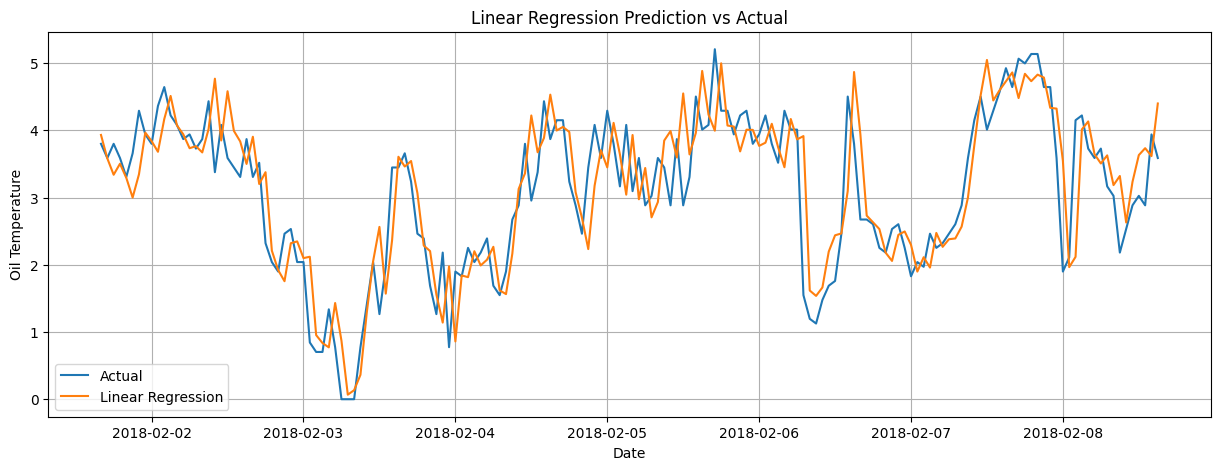

In [31]:
plot_n = 24 * 7

plt.figure(figsize=(15, 5))

plt.plot(
    test_ml["date"].iloc[:plot_n],
    y_test.iloc[:plot_n],
    label="Actual"
)

plt.plot(
    test_ml["date"].iloc[:plot_n],
    linear_pred[:plot_n],
    label="Linear Regression"
)

plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.title("Linear Regression Prediction vs Actual")
plt.legend()
plt.grid()

plt.show()

In [32]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
})

coef_df.sort_values(
    "Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
9,OT_lag1,0.946854
1,HULL,0.054912
2,MUFL,-0.047361
10,OT_lag24,0.031565
5,LULL,-0.026932
11,OT_lag168,0.019056
3,MULL,-0.019027
0,HUFL,0.018924
6,hour,-0.008118
4,LUFL,0.007254


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


In [34]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print("Baseline MAE :", mae)
print("Baseline RMSE:", rmse)

print()

print("Linear MAE   :", linear_mae)
print("Linear RMSE  :", linear_rmse)

print()

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Baseline MAE : 0.4480861066471695
Baseline RMSE: 0.6541843541468318

Linear MAE   : 0.4338290436134983
Linear RMSE  : 0.6328428018154258

Random Forest MAE : 0.5024765824115098
Random Forest RMSE: 0.7015831066839873


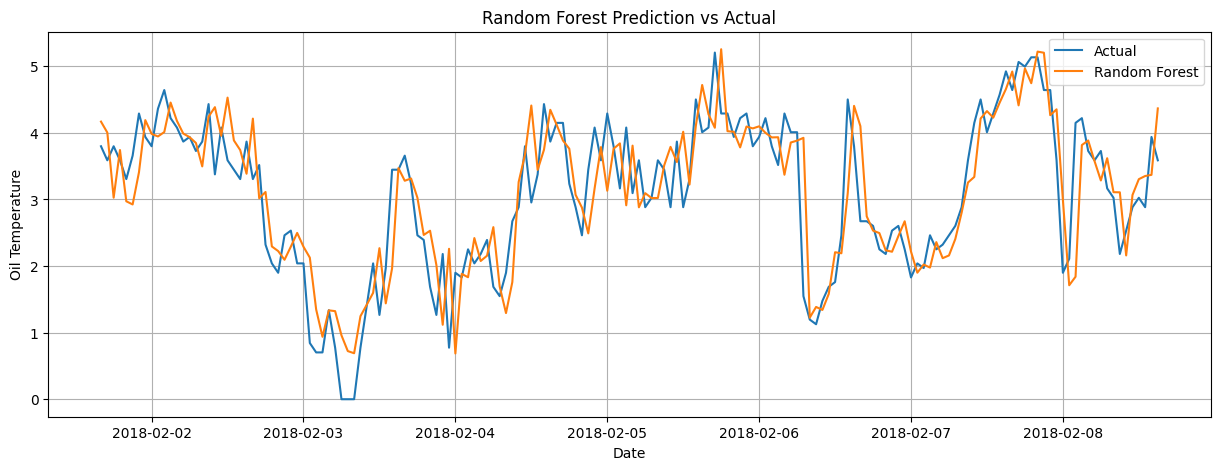

In [35]:
plot_n = 24 * 7

plt.figure(figsize=(15, 5))

plt.plot(
    test_ml["date"].iloc[:plot_n],
    y_test.iloc[:plot_n],
    label="Actual"
)

plt.plot(
    test_ml["date"].iloc[:plot_n],
    rf_pred[:plot_n],
    label="Random Forest"
)

plt.xlabel("Date")
plt.ylabel("Oil Temperature")
plt.title("Random Forest Prediction vs Actual")
plt.legend()
plt.grid()

plt.show()

In [36]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
9,OT_lag1,0.989234
10,OT_lag24,0.001857
11,OT_lag168,0.001407
2,MUFL,0.001086
4,LUFL,0.001039
6,hour,0.000981
0,HUFL,0.000953
3,MULL,0.000888
5,LULL,0.000881
1,HULL,0.000838


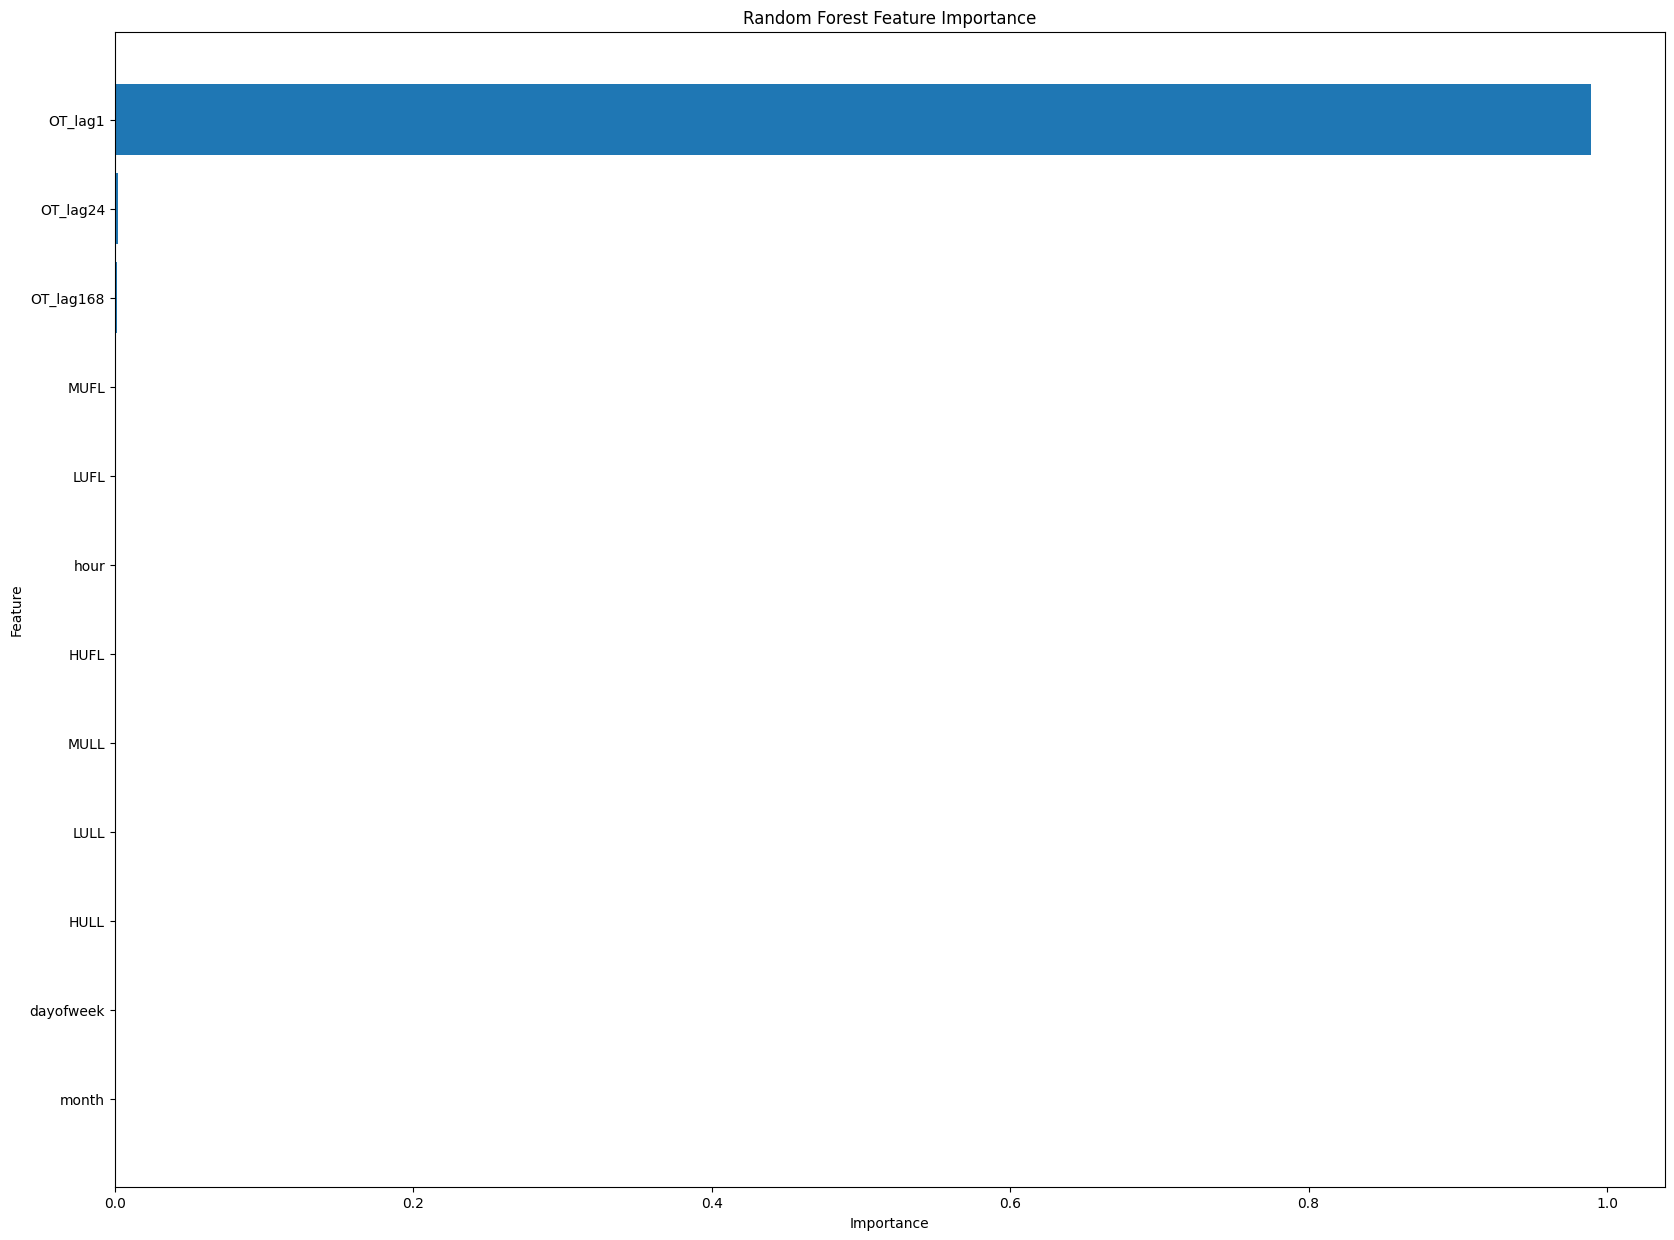

In [37]:
plt.figure(figsize=(20, 15))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [38]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [39]:
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

print("Baseline MAE      :", mae)
print("Baseline RMSE     :", rmse)

print()

print("Linear MAE        :", linear_mae)
print("Linear RMSE       :", linear_rmse)

print()

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)

print()

print("Gradient Boost MAE :", gb_mae)
print("Gradient Boost RMSE:", gb_rmse)

Baseline MAE      : 0.4480861066471695
Baseline RMSE     : 0.6541843541468318

Linear MAE        : 0.4338290436134983
Linear RMSE       : 0.6328428018154258

Random Forest MAE : 0.5024765824115098
Random Forest RMSE: 0.7015831066839873

Gradient Boost MAE : 0.4393821357568688
Gradient Boost RMSE: 0.6378583926708852


In [40]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae,
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        rmse,
        linear_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
1,Linear Regression,0.433829,0.632843
3,Gradient Boosting,0.439382,0.637858
0,Baseline,0.448086,0.654184
2,Random Forest,0.502477,0.701583


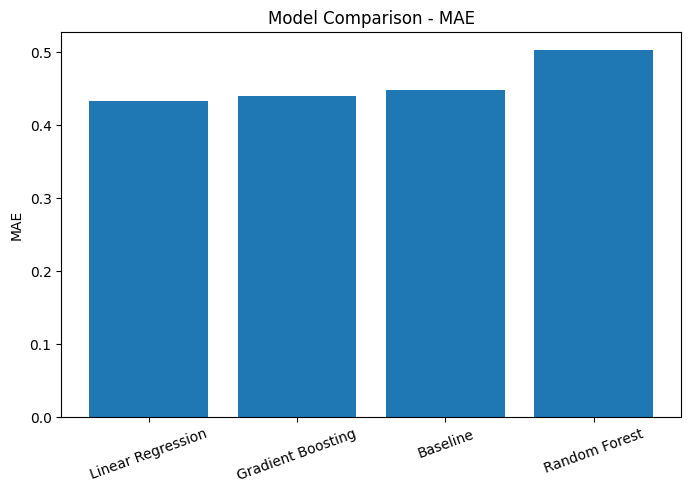

In [41]:
results_sorted = results.sort_values("MAE")

plt.figure(figsize=(8, 5))

plt.bar(
    results_sorted["Model"],
    results_sorted["MAE"]
)

plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.xticks(rotation=20)

plt.show()

In [42]:
# Linear Regressionの予測誤差を作成

error_df = test_ml[["date", "OT"]].copy()

error_df["pred"] = linear_pred

# 実測値 - 予測値
error_df["error"] = error_df["OT"] - error_df["pred"]

# 誤差の大きさ
error_df["abs_error"] = abs(error_df["error"])

error_df.head()

,date,OT,pred,error,abs_error
13936,2018-02-01 16:00:00,3.799,3.930989,-0.131989,0.131989
13937,2018-02-01 17:00:00,3.588,3.582077,0.005923,0.005923
13938,2018-02-01 18:00:00,3.799,3.338776,0.460224,0.460224
13939,2018-02-01 19:00:00,3.588,3.502382,0.085618,0.085618
13940,2018-02-01 20:00:00,3.306,3.292655,0.013345,0.013345


In [43]:
# 予測を大きく外したTOP10

worst_errors = error_df.sort_values(
    "abs_error",
    ascending=False
).head(10)

worst_errors

,date,OT,pred,error,abs_error
16074,2018-05-01 18:00:00,7.527,13.406057,-5.879057,5.879057
14948,2018-03-15 20:00:00,2.321,7.545803,-5.224803,5.224803
17246,2018-06-19 14:00:00,5.557,9.964824,-4.407824,4.407824
16188,2018-05-06 12:00:00,7.105,11.161604,-4.056604,4.056604
17003,2018-06-09 11:00:00,3.025,7.042355,-4.017355,4.017355
14947,2018-03-15 19:00:00,7.668,11.358548,-3.690547,3.690547
16159,2018-05-05 07:00:00,7.316,10.822849,-3.506849,3.506849
14686,2018-03-04 22:00:00,3.588,0.129901,3.458099,3.458099
16480,2018-05-18 16:00:00,9.426,12.734881,-3.308881,3.308881
17316,2018-06-22 12:00:00,3.658,6.946470,-3.288470,3.288470


In [44]:
# 1時間前からのOT変化量を追加

error_df["OT_change"] = (
    test_ml["OT"] - test_ml["OT_lag1"]
).values

error_df["abs_OT_change"] = abs(error_df["OT_change"])

# OTの急変量と予測誤差の相関
error_df[
    ["abs_error", "abs_OT_change"]
].corr()

,abs_error,abs_OT_change
abs_error,1.000000,0.862593
abs_OT_change,0.862593,1.000000




現在の油温と1時間前の油温の差を求め、変化量の大きさと予測誤差の関係を確認する。

両者の絶対値の相関係数は約0.863となった。油温の変化が大きい時点ほど、予測誤差も大きくなる傾向が見られる。

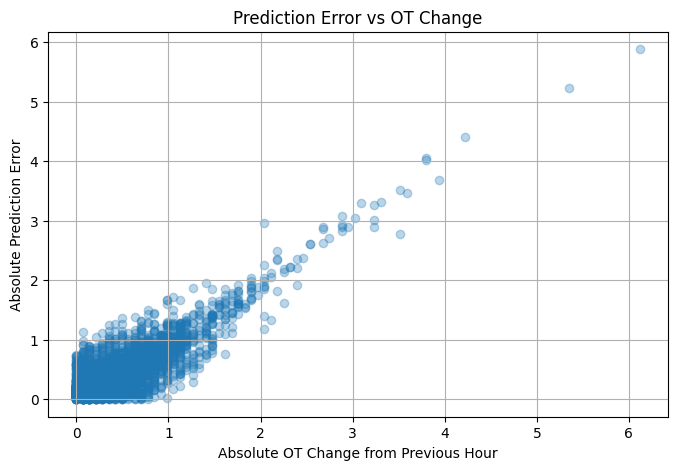

In [46]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_df["abs_OT_change"],
    error_df["abs_error"],
    alpha=0.3
)

plt.xlabel("Absolute OT Change from Previous Hour")
plt.ylabel("Absolute Prediction Error")
plt.title("Prediction Error vs OT Change")

plt.grid()
plt.show()

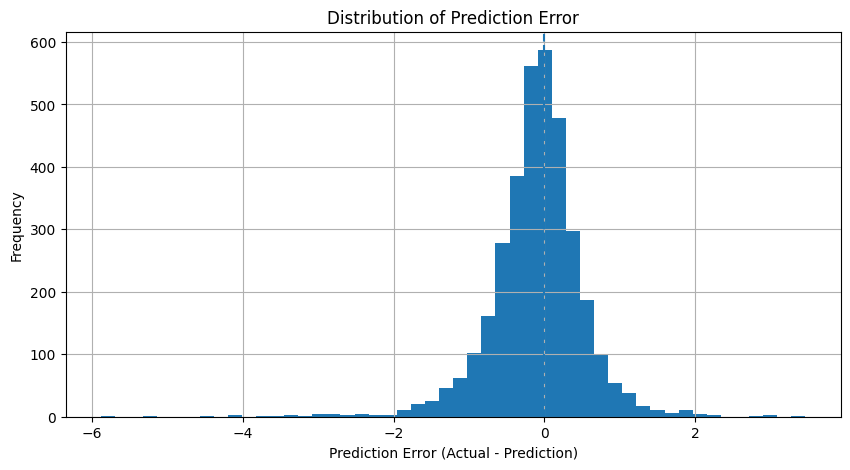

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    error_df["error"],
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Prediction Error (Actual - Prediction)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Error")

plt.grid()
plt.show()

In [53]:
print("Mean Error:", error_df["error"].mean())
print("Median Error:", error_df["error"].median())
print("Max Absolute Error:", error_df["abs_error"].max())

Mean Error: -0.10556046886823345
Median Error: -0.07364946949737794
Max Absolute Error: 5.8790565796816265



今回の条件では、線形回帰が最も小さい予測誤差となり、直前の油温を使う比較基準からMAEを約3.2%改善した。

一方で、油温の変化が大きい時点では誤差も大きくなる傾向が見られた。急な変化への追従が課題と考えられる。

今後は評価期間を変えて結果の再現性を確認し、通常時と急変時を分けて精度を評価する。また、過去の変化量や移動平均などの特徴量を追加し、改善につながるか検討する。

実際の利用に向けては、予測する時間幅と、その時点で利用できる入力情報を明確にする必要がある。